# **Naive Bayes**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve
)

In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nLabel distribution:\n", df["label"].value_counts())
print("\nLabel proportions:\n", df["label"].value_counts(normalize=True))

Shape: (5572, 2)

Missing values:
 label      0
message    0
dtype: int64

Label distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

Label proportions:
 label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


In [ ]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [ ]:
X = df["message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4457,)
Test size: (1115,)


In [ ]:
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform on train
X_test_tfidf = tfidf.transform(X_test)          # only transform on test (never fit on test!)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (4457, 3000)


In [ ]:
#training and making predictions
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)
y_proba = nb_model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nFull classification report:\n")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

Accuracy:  0.9749
Precision: 1.0000
Recall:    0.8121
F1-score:  0.8963

Full classification report:

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       1.00      0.81      0.90       149

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



In [ ]:
#predicting a random message
messages = [
    "Congratulations! You have won a free iPhone.",
    "Hey, are we still meeting tomorrow?"
]

messages_tfidf = tfidf.transform(messages)

predictions = nb_model.predict(messages_tfidf)

for msg, pred in zip(messages, predictions):
    if pred == 1:
        print(f"Spam: {msg}")
    else:
        print(f"Ham: {msg}")

Spam: Congratulations! You have won a free iPhone.
Ham: Hey, are we still meeting tomorrow?


**Experimenting to Improve Recall**: Since the initial model achieved high accuracy but relatively lower spam recall, several approaches were explored to potentially improve recall. These experiments included lowering the classification threshold to 0.3, making the model more likely to classify uncertain messages as spam, and enhancing the TF-IDF vectorizer by removing English stop words, increasing the vocabulary size, incorporating both unigrams and bigrams, and ignoring very rare words. The impact of these modifications was then evaluated by comparing the resulting performance metrics with those of the baseline model.

In [ ]:
# Try a lower threshold, e.g., 0.3 instead of default 0.5
custom_threshold = 0.3
y_pred_custom = (y_proba >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.96      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
#Improving the TF-IDF Vectorization
tfidf_improved = TfidfVectorizer(
    stop_words="english",
    max_features=5000,        # increased vocabulary size (was 3000)
    ngram_range=(1, 2),        # includes both single words AND two-word phrases
    min_df=2                   # ignore words that appear in only 1 message (likely noise)
)

X_train_tfidf2 = tfidf_improved.fit_transform(X_train)
X_test_tfidf2 = tfidf_improved.transform(X_test)

nb_model2 = MultinomialNB()
nb_model2.fit(X_train_tfidf2, y_train)

y_pred2 = nb_model2.predict(X_test_tfidf2)
print(classification_report(y_test, y_pred2, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



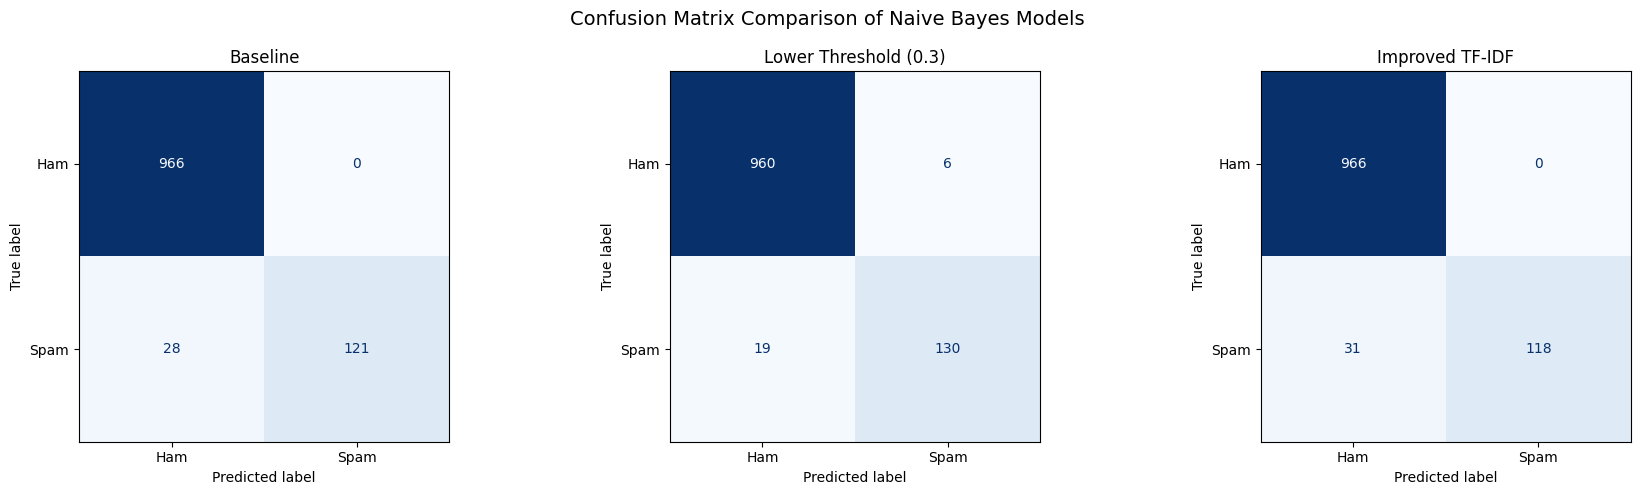

In [ ]:
#comparing the confusion matrix for all approaches
# Compute confusion matrices
cm_baseline = confusion_matrix(y_test, y_pred)
cm_threshold = confusion_matrix(y_test, y_pred_custom)
cm_tfidf = confusion_matrix(y_test, y_pred2)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Baseline
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["Ham", "Spam"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Baseline")

# Lower Threshold
ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["Ham", "Spam"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Lower Threshold (0.3)")

# Improved TF-IDF
ConfusionMatrixDisplay(
    confusion_matrix=cm_tfidf,
    display_labels=["Ham", "Spam"]
).plot(ax=axes[2], cmap="Blues", colorbar=False)
axes[2].set_title("Improved TF-IDF")

plt.suptitle("Confusion Matrix Comparison of Naive Bayes Models", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# comparing aacuracy all of the models variations
# Baseline model
acc1 = accuracy_score(y_test, y_pred)
prec1 = precision_score(y_test, y_pred)
rec1 = recall_score(y_test, y_pred)
f11 = f1_score(y_test, y_pred)

# Lower threshold model
acc2 = accuracy_score(y_test, y_pred_custom)
prec2 = precision_score(y_test, y_pred_custom)
rec2 = recall_score(y_test, y_pred_custom)
f12 = f1_score(y_test, y_pred_custom)

# Improved TF-IDF model
acc3 = accuracy_score(y_test, y_pred2)
prec3 = precision_score(y_test, y_pred2)
rec3 = recall_score(y_test, y_pred2)
f13 = f1_score(y_test, y_pred2)

# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Baseline MultinomialNB",
        "Lower Threshold (0.3)",
        "Improved TF-IDF"
    ],
    "Accuracy": [acc1, acc2, acc3],
    "Precision": [prec1, prec2, prec3],
    "Recall": [rec1, rec2, rec3],
    "F1-Score": [f11, f12, f13]
})

# Round values for neat display
comparison = comparison.round(4)

print(comparison)

                    Model  Accuracy  Precision  Recall  F1-Score
0  Baseline MultinomialNB    0.9749     1.0000  0.8121    0.8963
1   Lower Threshold (0.3)    0.9776     0.9559  0.8725    0.9123
2         Improved TF-IDF    0.9722     1.0000  0.7919    0.8839


**Key Takeaway**: The Multinomial Naive Bayes model achieved excellent overall performance, with perfect precision for spam detection, ensuring that no legitimate (Ham) messages were incorrectly classified as spam. However, the initial recall of 81% indicated that some spam messages were missed. To improve spam detection, different approaches were explored. Lowering the classification threshold proved to be the most effective strategy, increasing recall to 87% while only slightly reducing precision from 100% to 96%, resulting in a higher F1-score (0.896 → 0.910). In contrast, enhancing the TF-IDF vectorizer by adding bigrams and expanding the feature set did not improve performance and slightly reduced recall, likely due to increased feature sparsity. Overall, these results demonstrate that threshold tuning was a more effective and lower-risk approach for improving spam recall than modifying the feature extraction process.